In [1]:
import os
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from simpeg.electromagnetics.static import resistivity as dc
from simpeg.utils import model_builder
from simpeg.utils.io_utils.io_utils_electromagnetics import write_dcip2d_ubc
from simpeg import (
     maps,
     utils,
     survey,
     data,
     data_misfit,
     directives,
     seismic,
     optimization,
     regularization,
     inverse_problem,
     inversion
)
from simpeg.electromagnetics.static.utils.static_utils import (
    generate_dcip_sources_line,
    pseudo_locations,
    plot_pseudosection,
    apparent_resistivity_from_voltage,
)

from discretize import TreeMesh
from discretize.utils import active_from_xyz

# build the topography of the slope
define the 4:1 slope and undulatory topography

In [2]:
#define extents of the slope
x_topo = np.linspace(0, 1000, 400)
T = 250.0

#define the window of the slope we want to visualize
L = 1200
window = 0.5 * (1 + np.cos(np.pi * x_topo / L))
window[np.abs(x_topo) > L] = 0

#define the undulatory slope surface
z_topo = (10.0 * np.sin(2 * np.pi * x_topo / T) + 250) * window
topo_2d = np.c_[x_topo, z_topo]

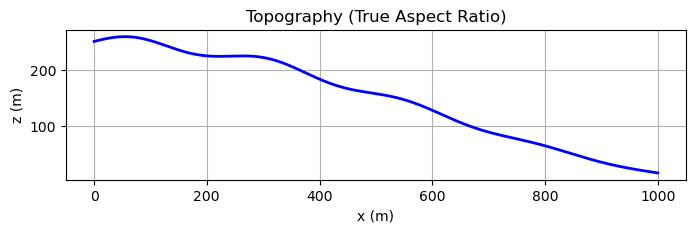

In [3]:
#visualize the topography of the slope with a true aspect ratio
fig, ax = plt.subplots(figsize=(8, 6)) 
ax.plot(x_topo, z_topo, color="b", linewidth=2)
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.grid(True)
ax.set_title("Topography (True Aspect Ratio)")
ax.set_aspect('equal') 
plt.show()

# define the survey
define the dipole-dipole survey with padding

In [4]:
#define the parameters of the survey
survey_type = "dipole-dipole"
dimension_type = "2D"
data_type = "volt"
end_locations = np.r_[250, 750] 
station_spacing = 30
num_rx_per_src = 10

In [5]:
#define a function to assign the electrode locations to the appropriate elevations
interp_fun = interp1d(x_topo, z_topo)

In [6]:
#assign the electrode locations
electrode_locations_x = np.arange(
    end_locations[0], end_locations[1] + station_spacing, station_spacing
)
electrode_locations_z = interp_fun(electrode_locations_x)
electrode_locations = np.c_[electrode_locations_x, electrode_locations_z]
n_electrodes = len(electrode_locations_x)

In [7]:
#generate the source list from the given survey
source_list = generate_dcip_sources_line(
    survey_type,
    data_type,
    dimension_type,
    end_locations,
    topo_2d,
    num_rx_per_src,
    station_spacing,
)
survey = dc.Survey(source_list)

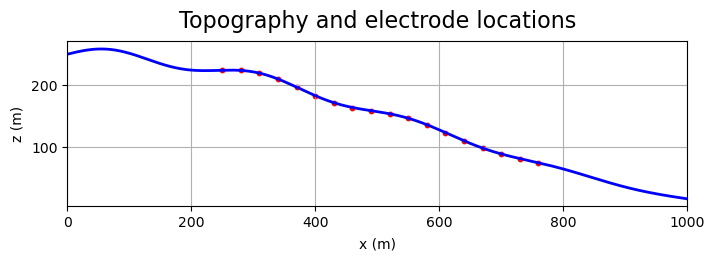

In [8]:
#visualize the electrode locations along the true topography
fig, ax = plt.subplots(figsize=(8, 6)) 
ax.plot(x_topo, z_topo, color="b", linewidth=2)
ax.scatter(electrode_locations_x, electrode_locations_z, 10, "r")
ax.set_xlim([x_topo.min(), x_topo.max()])
ax.set_xlabel("x (m)", labelpad=5)
ax.set_ylabel("z (m)", labelpad=5)
ax.grid(True)
ax.set_aspect('equal') 
ax.set_title("Topography and electrode locations", fontsize=16, pad=10)
plt.show(fig)

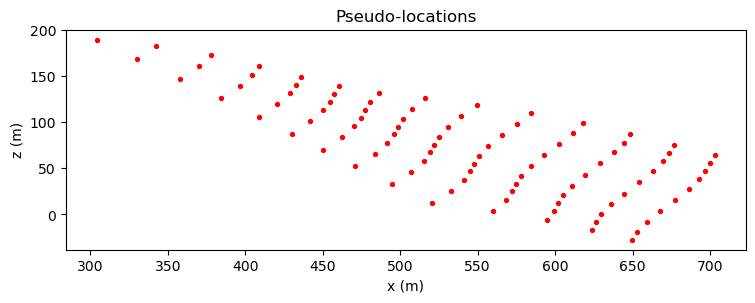

In [9]:
#visualize the pseudo-sensitivity locations of the survey
pseudo_locations_xz = pseudo_locations(survey)
fig = plt.figure(figsize=(8, 2.75))
ax = fig.add_axes([0.1, 0.1, 0.85, 0.8])
ax.scatter(pseudo_locations_xz[:, 0], pseudo_locations_xz[:, -1], 8, "r")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title("Pseudo-locations")
plt.show()

# define the mesh for the synthetic model
define a tree mesh with finer cells near the electrodes

In [10]:
#define the base cell width 
dh = 4  
dom_width_x = 3200.0  
dom_width_z = 2400.0 
nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0))) 
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0))) 

#define the base/finest mesh at the electrodes
hx = [(dh, nbcx)]
hz = [(dh, nbcz)]
mesh = TreeMesh([hx, hz], x0="CN", diagonal_balance=True)

#define the top of the mesh at the slope surface
mesh.origin = mesh.origin + np.r_[0.0, z_topo.max()]
mesh.refine_surface(
    topo_2d,
    padding_cells_by_level=[0, 0, 4, 4],
    finalize=False,
)

#extract electrode locations
unique_locations = survey.unique_electrode_locations

# Mesh refinement near electrodes.
mesh.refine_points(
    unique_locations, padding_cells_by_level=[8, 12, 6, 6], finalize=False
)
mesh.finalize()

In [11]:
#verify number of cells and mesh extent
mesh

QuadTreeMesh,1.15% filled
Level,Number of cells
3,17
4,33
5,46
6,70
7,383
8,632
9,2036
10,2800
Total,6017


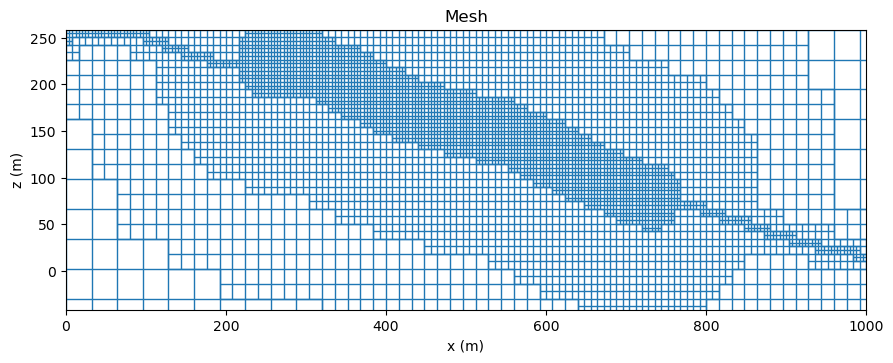

In [12]:
#visualize tree mesh
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_axes([0.14, 0.17, 0.8, 0.7])
mesh.plot_grid(ax=ax1, linewidth=1)
ax1.grid(False)
ax1.set_xlim(0, 1000)
ax1.set_ylim(np.max(z_topo) - 300, np.max(z_topo))
ax1.set_title("Mesh")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
plt.show()

In [13]:
#retrieve the indices of the active cells (below the air)
active_cells = active_from_xyz(mesh, topo_2d)

#retrieve the number of active cells
n_active = np.sum(active_cells)

# design the conductivity model
define the geologic units and assign appropriate conductivities

In [14]:
#define the conductivities of the air, geologic background, and conductive clay unit in S/m
air_conductivity = 1e-8
background_conductivity = 0.01
conductor_conductivity = 1

In [15]:
#retrieve the active cell centres
x = mesh.gridCC[active_cells, 0]
z = mesh.gridCC[active_cells, 1]

#assign the background conductivity to the model
conductivity_model = background_conductivity * np.ones(n_active)

#define the weak clay layer
z_surface = np.interp(x, x_topo, z_topo)
inds_weak = (z < z_surface - 35) & (z > z_surface - 55)

#assign the conductivity to the clay layer
conductivity_model[inds_weak] = conductor_conductivity

#create the log conductivity model
log_conductivity_model = np.log(conductivity_model)

#create the log resistivity model
log_resistivity_model = np.log(1 / conductivity_model)

In [16]:
#create the conductivity map
conductivity_map = maps.InjectActiveCells(mesh, active_cells, air_conductivity)

#create the log conductivity map
log_conductivity_map = maps.InjectActiveCells(mesh, active_cells, air_conductivity) * maps.ExpMap(nP=n_active)

#create the log resistivity map
log_resistivity_map = maps.InjectActiveCells(mesh, active_cells, 1 / air_conductivity) * maps.ExpMap(nP=n_active)

In [17]:
#generate a map that ignores inactive air cells
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)

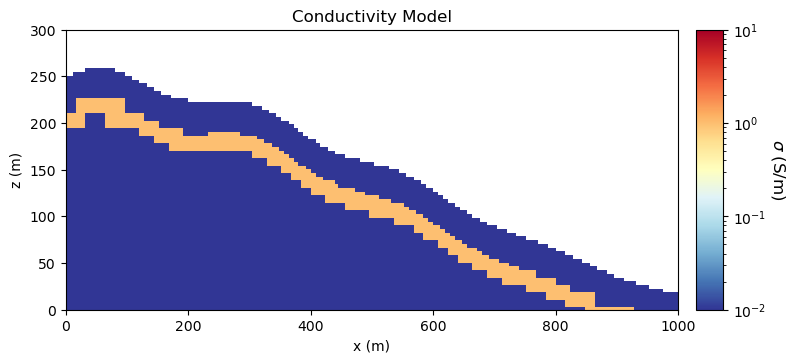

In [18]:
#visualize the conductivity model
fig = plt.figure(figsize=(9, 4))

norm = LogNorm(vmin=1e-2, vmax=10)

ax1 = fig.add_axes([0.14, 0.17, 0.68, 0.7])
mesh.plot_image(
    plotting_map * conductivity_model,
    ax=ax1,
    grid=False,
    pcolor_opts={"norm": norm, "cmap": mpl.cm.RdYlBu_r},
)
ax1.set_xlim(0, 1000)
ax1.set_ylim(0, 300)
ax1.set_title("Conductivity Model")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.84, 0.17, 0.03, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label(r"$\sigma$ (S/m)", rotation=270, labelpad=15, size=12)

plt.show()

# forward simulation
run the forward simulation

In [19]:
#project electrodes to the surface of the slope
survey.drape_electrodes_on_topography(mesh, active_cells, topo_cell_cutoff="top")

In [20]:
#run a DC forward simulation for the conductivity model
simulation_con = dc.simulation_2d.Simulation2DNodal(
    mesh, survey=survey, sigmaMap=conductivity_map
)

#run a DC forward simulation for the log conductivity model
simulation_con_log = dc.simulation_2d.Simulation2DNodal(
    mesh, survey=survey, sigmaMap=log_conductivity_map
)

#run a DC forward simulation for the log-resistivity model
simulation_res = dc.simulation_2d.Simulation2DNodal(
    mesh, survey=survey, rhoMap=log_resistivity_map
)

INFO: Setting the default solver 'Pardiso' for the 'Simulation2DNodal'.
To avoid receiving this message, pass a solver to the simulation. For example:

  from simpeg.utils import get_default_solver

  solver = get_default_solver()
  simulation = Simulation2DNodal(solver=solver, ...)
INFO: Setting the default solver 'Pardiso' for the 'Simulation2DNodal'.
To avoid receiving this message, pass a solver to the simulation. For example:

  from simpeg.utils import get_default_solver

  solver = get_default_solver()
  simulation = Simulation2DNodal(solver=solver, ...)
INFO: Setting the default solver 'Pardiso' for the 'Simulation2DNodal'.
To avoid receiving this message, pass a solver to the simulation. For example:

  from simpeg.utils import get_default_solver

  solver = get_default_solver()
  simulation = Simulation2DNodal(solver=solver, ...)


In [21]:
#define the predicted data from the forward simulation
dpred_con = simulation_con.dpred(conductivity_model)

#define the predicted data in log space from the forward simulation
dpred_con_log = simulation_con_log.dpred(log_conductivity_model)

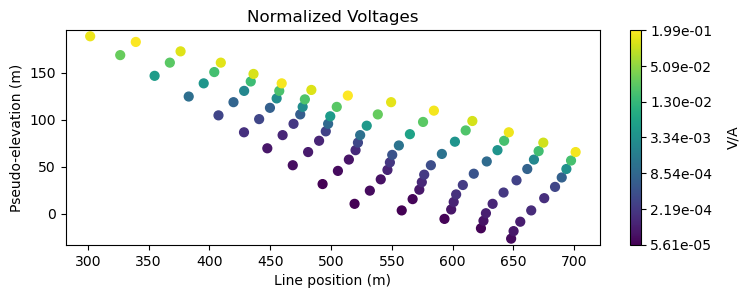

In [22]:
#visualize the voltages pseudo-section
fig = plt.figure(figsize=(8, 2.75))
ax1 = fig.add_axes([0.1, 0.15, 0.75, 0.78])
plot_pseudosection(
    survey,
    dobs=np.abs(dpred_con),
    plot_type="scatter",
    ax=ax1,
    scale="log",
    cbar_label="V/A",
    scatter_opts={"cmap": mpl.cm.viridis},
)
ax1.set_title("Normalized Voltages")
plt.show()

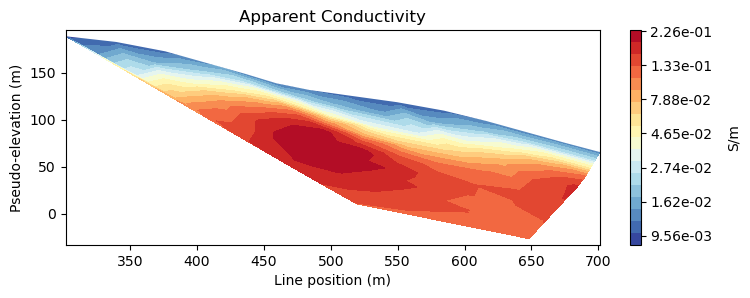

In [23]:
#obtain apparent conductivities and resistivities from the voltage data
apparent_conductivities = 1 / apparent_resistivity_from_voltage(survey, dpred_con_log)
apparent_resistivities = apparent_resistivity_from_voltage(survey, dpred_con_log)

#visualize the apparent conductivity pseudo-section
fig = plt.figure(figsize=(8, 2.75))
ax1 = fig.add_axes([0.1, 0.15, 0.75, 0.78])
plot_pseudosection(
    survey,
    dobs=apparent_conductivities,
    plot_type="contourf",
    ax=ax1,
    scale="log",
    cbar_label="S/m",
    mask_topography=True,
    contourf_opts={"levels": 20, "cmap": mpl.cm.RdYlBu_r},
)
ax1.set_title("Apparent Conductivity")
plt.show()

# inversion
define parameters for the inversion

In [24]:
#calculate the median apparent resistivity for the starting model
median_resistivity = np.median(apparent_resistivities)

#create the starding conductivity model
starting_conductivity_model = np.log(1 / median_resistivity) * np.ones(n_active)

#create a zero reference conductivity model
reference_conductivity_model = starting_conductivity_model.copy()

In [25]:
conductivity_data = data.Data(survey, dobs=dpred_con_log)

In [26]:
#assign a standard deviation
conductivity_data.standard_deviation = 1e-5 + 0.05 * np.abs(conductivity_data.dobs)

In [27]:
#define the data misfit function
dmis_L2 = data_misfit.L2DataMisfit(simulation=simulation_con_log, data=conductivity_data)

In [28]:
#define the weighted least squares regularization and assign alpha parameters
reg_L2 = regularization.WeightedLeastSquares(
    mesh,
    active_cells=active_cells,
    alpha_s=dh**-2,
    alpha_x=0.5,
    alpha_y=0.5,
    reference_model=reference_conductivity_model,
    reference_model_in_smooth=False,
)

In [29]:
#define inexact gauss newton optimization
opt_L2 = optimization.InexactGaussNewton(
    maxIter=20,
    maxIterLS=20,
    cg_maxiter=20,
    cg_rtol=1e-3,
)

In [30]:
#define the inverse problem and map
inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_L2, reg_L2, opt_L2)
exp_map = maps.ExpMap(mesh)
inv_prob_L2.mapping = maps.ExpMap(mesh) 

# create the tikhonov curves
build phi_m, phi_d, and beta curves validate choice of trade-off parameter

In [32]:
#select a range of beta values
beta_values = np.logspace(-3, 2, 10)

#initiate lists for phi_d and phi_m
phi_d_list = []
phi_m_list = []

#create for loop for each beta value
for beta in beta_values:
    
    opt = optimization.InexactGaussNewton(maxIter=8)

    #set up the inverse problem
    inv_prob = inverse_problem.BaseInvProblem(dmis_L2, reg_L2, opt)
    inv_prob.beta = beta
    inv = inversion.BaseInversion(inv_prob, directiveList=[])

    #run the inversion
    recovered_model = inv.run(starting_conductivity_model)

    #save phi_d and phi_m at each beta
    phi_d_list.append(inv_prob.phi_d)
    phi_m_list.append(inv_prob.phi_m)

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.00e-03  1.00e+04  0.00e+00  1.00e+04                                 
   1  1.00e-03  4.67e+03  3.31e+03  4.67e+03    1.41e+02      1              
   2  1.00e-03  3.94e+03  4.74e+03  3.94e+03    4.81e+02      0              
   3  1.00e-03  4.89e+02  4.42e+03  4.93e+02    1.59e+03      0              
   4  1.00e-03  1.07e+02  5.00e+03  1.12e+02    2.10e+02      0   Skip BFGS  
   5  1.00e-03  5.47e+01  5.10e+03  5.98e+01    6.22e+01      0              
   6  1.00e-03  4.34e+01  5.22e+03  4.86e+01    3.94e+01      0              
   7  1.00e-03  3.67e+01  5.38e+03  4.21e+01    2.02e+01      0              
   8  1.00e-03  3.21e+01  5.43e+03  3.75e+01    1.74e+01      0              


INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.



------------------------- STOP! -------------------------
1 : |fc-fOld| = 4.6253e+00 <= tolF*(1+|f0|) = 1.0044e+03
1 : |xc-x_last| = 1.3872e+00 <= tolX*(1+|x0|) = 1.3486e+01
0 : |proj(x-g)-x|    = 2.1764e+01 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 2.1764e+01 <= 1e3*eps       = 1.0000e-02
1 : maxIter   =       8    <= iter          =      8
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  3.59e-03  1.00e+04  0.00e+00  1.00e+04                                 
   1  3.59e-03  4.67e+03  3.27e+03  4.69e+03    1.41e+02      1              
   2  3.59e-03  3.93e+03  4.75e+03  3.95e+03    4.79e+02      0              
   3  3.59e-03  4.84e+02  4.42e+03  5.00e+02    1.58e+03      0              
 

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.



...

------------------------- STOP! -------------------------
1 : |fc-fOld| = 2.6624e+01 <= tolF*(1+|f0|) = 1.0044e+03
1 : |xc-x_last| = 2.5716e+00 <= tolX*(1+|x0|) = 1.3486e+01
0 : |proj(x-g)-x|    = 7.7531e+01 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 7.7531e+01 <= 1e3*eps       = 1.0000e-02
1 : maxIter   =       8    <= iter          =      8
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  7.74e+00  1.00e+04  0.00e+00  1.00e+04                                 
   1  7.74e+00  9.23e+03  4.49e+01  9.58e+03    1.41e+02      0              
   2  7.74e+00  9.07e+03  6.28e+01  9.56e+03    2.97e+01      0   Skip BFGS  
   3  7.74e+00  9.03e+03  6.81e+01  9.56e+03    6.89e+00      0   Skip BFGS  
 

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.



------------------------- STOP! -------------------------
1 : |fc-fOld| = 3.9476e-04 <= tolF*(1+|f0|) = 1.0044e+03
1 : |xc-x_last| = 6.1298e-03 <= tolX*(1+|x0|) = 1.3486e+01
1 : |proj(x-g)-x|    = 4.9644e-02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 4.9644e-02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =       8    <= iter          =      6
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  2.78e+01  1.00e+04  0.00e+00  1.00e+04                                 
   1  2.78e+01  9.80e+03  4.13e+00  9.91e+03    1.41e+02      0              
   2  2.78e+01  9.79e+03  4.56e+00  9.91e+03    1.09e+01      0   Skip BFGS  
   3  2.78e+01  9.79e+03  4.62e+00  9.91e+03    1.22e+00      0   Skip BFGS  
 

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.



------------------------- STOP! -------------------------
1 : |fc-fOld| = 1.0431e-04 <= tolF*(1+|f0|) = 1.0044e+03
1 : |xc-x_last| = 1.5778e-03 <= tolX*(1+|x0|) = 1.3486e+01
1 : |proj(x-g)-x|    = 1.7968e-02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 1.7968e-02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =       8    <= iter          =      4
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.00e+02  1.00e+04  0.00e+00  1.00e+04                                 
   1  1.00e+02  9.97e+03  3.46e-01  1.00e+04    1.41e+02      0              
   2  1.00e+02  9.97e+03  3.55e-01  1.00e+04    8.61e+00      0   Skip BFGS  
   3  1.00e+02  9.97e+03  3.59e-01  1.00e+04    8.71e-01      0              
-

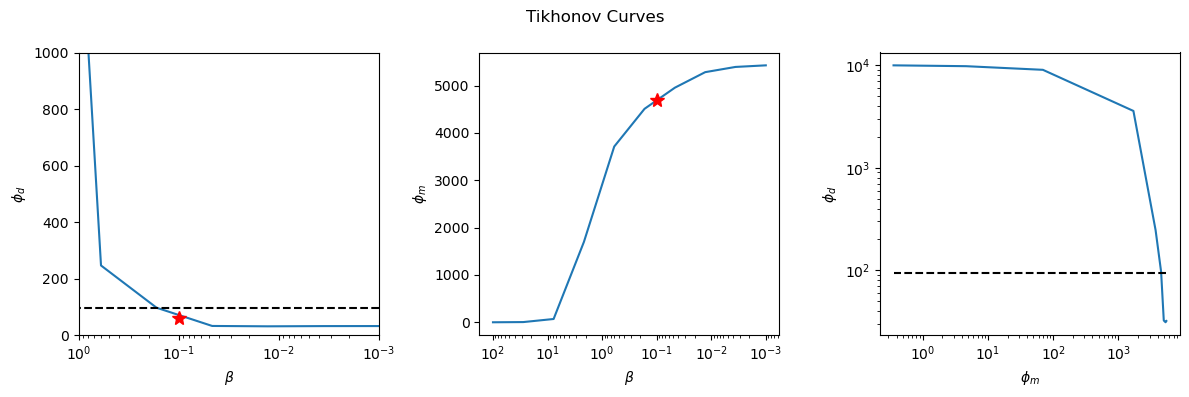

In [48]:
#visualize the tikhonov curves
fig, ax = plt.subplots(1, 3, figsize=(12, 4)) 

ax[0].semilogx(beta_values, phi_d_list)
ax[1].semilogx(beta_values, phi_m_list)
ax[2].loglog(phi_m_list, phi_d_list) 
ax[0].set_ylabel("$\\phi_d$")
ax[1].set_ylabel("$\\phi_m$")
ax[2].set_xlabel("$\\phi_m$")
ax[2].set_ylabel("$\\phi_d$")
ax[0].set_xlim(1e-3, 1)
ax[0].set_ylim(0, 1000)

# add our target misfit 
ax[0].semilogx(beta_values, np.ones(len(beta_values))*len(dpred_con), "--k")
ax[2].loglog(phi_m_list, np.ones(len(phi_m_list))*len(dpred_con), "--k")

beta_values = np.array(beta_values)
idx = np.argmin(np.abs(beta_values - 0.1))  # closest beta to 1

# ax[0].plot(beta_values[idx], phi_d_list[idx], marker="*", markersize=10, color="red")
# ax[1].plot(beta_values[idx], phi_m_list[idx], marker="*", markersize=10, color="red")
ax[0].plot(.1, 60, marker="*", markersize=10, color="red")
ax[1].plot(.1, 4700, marker="*", markersize=10, color="red")

for a in ax[:2]:
    a.invert_xaxis()
    a.set_xlabel("$\\beta$")

plt.suptitle("Tikhonov Curves")
plt.tight_layout()

# run the inversion at an optimal beta ratio
run and visualize the optimal inversion according to the tikhonov curve

In [41]:
#define sensitivity weighting
sensitivity_weights = directives.UpdateSensitivityWeights(
    every_iteration=True, threshold_value=0.1
)
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=0.1)
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=2)
target_misfit = directives.TargetMisfit(chifact=1)

#define directives
directives_list_L2 = [
    sensitivity_weights,
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
]

In [42]:
#combine the inverse problem and directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

#run the inversion
recovered_log_conductivity_model = inv_L2.run(starting_conductivity_model)


Running inversion with SimPEG v0.25.0


INFO: Directive TargetMisfit: Target data misfit is 95.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.60e-03  1.00e+04  0.00e+00  1.00e+04                                 
   1  1.60e-03  4.65e+03  8.77e+02  4.65e+03    1.41e+02      2              
   2  1.60e-03  1.53e+03  1.50e+03  1.53e+03    5.30e+02      1              
   3  8.02e-04  2.27e+02  1.78e+03  2.28e+02    4.65e+02      0              
   4  8.02e-04  1.93e+01  1.58e+03  2.06e+01    2.55e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 2.0754e+02 <= tolF*(1+|f0|) = 1.0044e+03
0 : |xc-x_last| = 3.1210e+01 <= tolX*(1+|x0|) = 1.3486e+01
0 : |proj(x-g)-x|    = 2.5499e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 2.5499e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      20    <= iter          =      4
--------------------

In [43]:
#convert log-conductivity values to conductivity values
recovered_conductivity_L2 = np.exp(recovered_log_conductivity_model)

In [44]:
#define a map to plot models and ignore inactive cells
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)

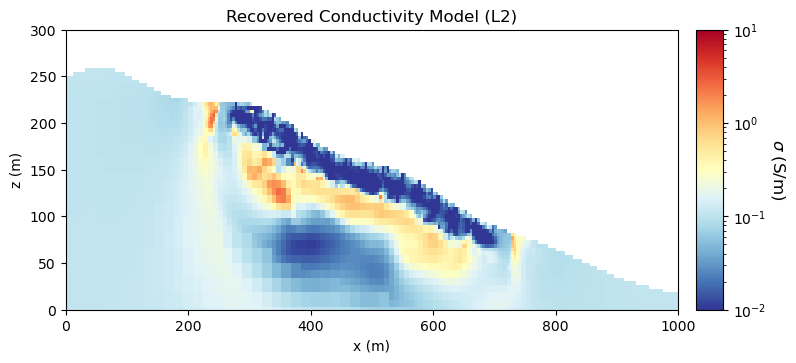

In [45]:
#visualize inversion results
norm = LogNorm(vmin=0.01, vmax=10)
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_axes([0.14, 0.17, 0.68, 0.7])
mesh.plot_image(
    plotting_map * recovered_conductivity_L2,
    normal="Y",
    ax=ax1,
    grid=False,
    pcolor_opts={"norm": norm, "cmap": mpl.cm.RdYlBu_r},
)
ax1.set_xlim(0, 1000)
ax1.set_ylim(0, 300)
ax1.set_title("Recovered Conductivity Model (L2)")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
ax2 = fig.add_axes([0.84, 0.17, 0.03, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label(r"$\sigma$ (S/m)", rotation=270, labelpad=15, size=12)
plt.show()